### Text Rating Prediction

Text Rating Prediction — это задача машинного обучения, которая заключается в предсказании рейтинга (например, от 1 до 5 звёзд) на основе текста отзыва. В последние годы с ростом онлайн-торговли и платформ для отзывов, таких как Amazon, eBay, и Google Reviews, значимость такой задачи значительно возросла, поскольку качественная система предсказания рейтингов помогает автоматизировать оценку продуктов и услуг, улучшая взаимодействие с пользователями и ускоряя обработку больших объемов данных.

#### Цель задачи

Целью данной задачи является создание модели, которая сможет предсказывать рейтинг товара или услуги, исходя только из текстового отзыва пользователя. Эта модель будет использовать текстовые данные (например, описания, мнения и комментарии пользователей) для оценки и предсказания, насколько положительным или отрицательным будет рейтинг.

Задача имеет важное практическое применение в таких областях, как:

* Автоматическое модерирование отзывов: определение позитивных и негативных отзывов для автоматической фильтрации.

* Оценка качества товаров и услуг на основании пользовательских отзывов.

*  Повышение точности рекомендательных систем, которые могут прогнозировать рейтинг продукта для каждого пользователя, основываясь на исторических данных и текстах отзывов.

#### Методы решения

Для решения этой задачи можно использовать различные подходы:

* Обработка текста (NLP): Преобразование текста в числовые признаки с помощью таких методов, как CountVectorizer или TF-IDF, или использование более сложных методов, таких как Word2Vec, GloVe и BERT.

* Модели машинного обучения: После извлечения признаков из текста можно применить различные модели классификации, такие как Logistic Regression, Random Forest, XGBoost или Neural Networks.

* Использование предварительно обученных эмбеддингов: Модели типа BERT или DistilBERT могут быть использованы для создания более мощных представлений текста, что существенно повысит точность предсказания.

#### Значимость и вызовы

Основной вызов в задаче Text Rating Prediction заключается в том, чтобы правильно интерпретировать смысл текста и учитывать контекст, который может сильно повлиять на рейтинг. Например, одни и те же слова могут иметь различные коннотации в зависимости от контекста, и это важно учитывать при обучении модели. Также модель должна справляться с проблемой многозначности и слабой корреляции между текстом и рейтингом в некоторых случаях.

Таким образом, успешное решение задачи предсказания рейтинга по тексту может значительно повысить эффективность обработки отзывов и улучшить пользовательский опыт в онлайн-торговле и других сферах, где важны мнения и оценки пользователей.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
#from sklearn.feature_selection import 
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
import spacy
import os
from gensim.models import Word2Vec
import gensim.downloader as api
from transformers import BertTokenizer, AutoModelForSequenceClassification
from nltk.tokenize import WordPunctTokenizer

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
import tensorflow
from keras.models import Sequential
from keras.layers import Activation, Dense, LSTM, GRU, Flatten, Dropout, Embedding, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer                               # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences                       # type: ignore
from tensorflow.keras.optimizers import Adam                                            # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau                 # type: ignore

In [6]:
from utils.baseline import *

### 1. Загрузка данных

Производим загрузку предобработанных данных для дальнейшей подготовки их для обучения моделей. Признаком в этих данных является `review_text`, который будет изменен и преобразован в очищенный текст, а целевая переменная `rating`. Рейтинг будет изменен с 1-5 до 0-1 фактически сводя задачу мультиклассификации к задаче бинарной классификации.

In [7]:
data = pd.read_csv('./data/Mobile Reviews Sentiment Pred.csv', index_col=0, parse_dates=['review_date'])

In [8]:
data.head(3)

,age,brand,model,price_usd,rating,review_text,sentiment,country,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,word_count,helpful_votes,source
0,45,Realme,Realme 12 Pro,337.31,2,Not worth the money spent. Wouldn’t recommend.,0,India,2023-11-06,1,1,1,3,2,1,7,1,Amazon
1,18,Realme,Realme 12 Pro,307.78,4,Absolutely love this phone! The camera is next...,2,Brazil,2023-03-30,1,3,2,4,3,2,12,5,Flipkart
2,27,Google,Pixel 6,864.53,4,Loving the clean UI and fast updates. Loving i...,2,India,2022-12-07,1,3,5,3,2,4,11,8,AliExpress


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   age                  50000 non-null  int64         
 1   brand                50000 non-null  object        
 2   model                50000 non-null  object        
 3   price_usd            50000 non-null  float64       
 4   rating               50000 non-null  int64         
 5   review_text          50000 non-null  object        
 6   sentiment            50000 non-null  int64         
 7   country              50000 non-null  object        
 8   review_date          50000 non-null  datetime64[ns]
 9   verified_purchase    50000 non-null  int64         
 10  battery_life_rating  50000 non-null  int64         
 11  camera_rating        50000 non-null  int64         
 12  performance_rating   50000 non-null  int64         
 13  design_rating        50000 non-null 

### 2. Преобразование данных

В данном фрагменте кода производится подготовка данных для задачи Text Rating Prediction, где целью является предсказание рейтинга продукта на основе текстового отзыва. 

На первом этапе создаётся объект класса PreprocessingText, который содержит метод clean_text, предназначенный для очистки текстовых данных. Этот метод применяется к каждому отзыву в колонке review_text. После обработки результат сохраняется в новой колонке clean_text. Очистка текста может включать в себя такие операции, как:

* удаление стоп-слов,

* приведение текста к нижнему регистру,

* удаление пунктуации и чисел,

* лемматизация.

In [10]:
path = './data/clean_text.txt'

if os.path.exists(path):
    with open(path, mode='r', encoding='utf-8') as f:
        data['clean_text'] = [line.strip() for line in f.readlines()]

else:
    prep = PreprocessingText()
    data['clean_text'] = prep.process_texts_in_parallel(data['review_text'])
    
    with open(path, mode='w', encoding='utf-8') as f:
        f.writelines(data['clean_text'].apply(lambda x: x + '\n'))

Здесь изначально выделяются категориальные и числовые признаки:

* categorical_columns — это список всех столбцов, содержащих категориальные данные.

* numeric_columns — это список столбцов с числовыми значениями, такими как возраст, рейтинг и другие количественные признаки.

В процессе фильтрации из списка категориальных признаков исключаются `review_text` и `clean_text`, так как эти столбцы не требуют преобразования через one-hot encoding.

In [11]:
categorical_columns = data.select_dtypes(include=['object']).columns.to_list()
numeric_columns = data.select_dtypes(include=['int', 'float']).columns.to_list()

mask = ['review_text', 'clean_text']
categorical_columns = [col for col in categorical_columns if col not in mask]

Для преобразования категориальных признаков используется метод pd.get_dummies(), который выполняет one-hot encoding для всех категориальных признаков в данных. Это преобразует категориальные значения в бинарные столбцы. Параметр drop_first=True используется для исключения первой категории в каждом признаке, что помогает избежать мультиколлинеарности.

In [12]:
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

Целевая переменная `rating` преобразуется для бинарной классификации. Рейтинги 1 и 2 превращаются в 0 (плохие оценки), а 4 и 5 — в 1 (хорошие оценки). Это позволяет классифицировать отзывы как позитивные или негативные, что упрощает задачу и фокусируется на наиболее значимых признаках.

In [13]:
data['rating'] = data['rating'].map({1 : 0, 2 : 0, 4 : 1, 5 : 1})

Здесь удаляются строки с пропущенными значениями в колонке `rating`, так как модель не сможет обучаться с отсутствующими метками для целевой переменной.

In [14]:
data = data.dropna(subset=['rating'])

После этого столбец `rating` преобразуется в тип int, чтобы убедиться, что значения могут быть правильно интерпретированы как целочисленные для классификации.

In [15]:
data['rating'] = data['rating'].astype('int')

Cоздаём новый признак `rating_phone`, который является средним значением по оценкам различных характеристик телефона: `battery_life_rating`, `camera_rating`, `performance_rating`, `design_rating`, и `display_rating`. Этот признак может быть полезен для улучшения предсказания рейтинга, так как включает в себя объективные характеристики устройства.

In [16]:
data['rating_phone'] = data[['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']].mean(axis=1)

После создания нового признака `rating_phone`, исходные столбцы, содержащие индивидуальные оценки характеристик, удаляются, чтобы избежать избыточности и упрощения модели.

In [17]:
data = data.drop(columns=['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating'], axis=1)

Теперь выделяются признаки (X) и целевая переменная (y). В данном случае X_review — это текстовый столбец `review_text`, который будет использоваться для предсказания рейтинга, а y — это столбец `rating`, который содержит метки классов (позитивный или негативный рейтинг).

In [18]:
X = data['clean_text']
y = data['rating']

In [19]:
print(f'Среднее количество слов в отзыве: {round(data['word_count'].mean())}')

Среднее количество слов в отзыве: 11


In [20]:
data.columns

Index(['age', 'price_usd', 'rating', 'review_text', 'sentiment', 'review_date',
       'verified_purchase', 'word_count', 'helpful_votes', 'clean_text',
       'brand_Google', 'brand_Motorola', 'brand_OnePlus', 'brand_Realme',
       'brand_Samsung', 'brand_Xiaomi', 'model_Galaxy A55',
       'model_Galaxy Note 20', 'model_Galaxy S24', 'model_Galaxy Z Flip',
       'model_Mi 13 Pro', 'model_Moto G Power', 'model_OnePlus 11R',
       'model_OnePlus 12', 'model_OnePlus Nord 3', 'model_Pixel 6',
       'model_Pixel 7a', 'model_Pixel 8', 'model_Poco X6', 'model_Razr 40',
       'model_Realme 12 Pro', 'model_Realme Narzo 70', 'model_Redmi Note 13',
       'model_iPhone 13', 'model_iPhone 14', 'model_iPhone 15 Pro',
       'model_iPhone SE', 'country_Brazil', 'country_Canada',
       'country_Germany', 'country_India', 'country_UAE', 'country_UK',
       'country_USA', 'source_Amazon', 'source_BestBuy', 'source_Flipkart',
       'source_eBay', 'rating_phone'],
      dtype='object')

### 3. Baseline

Необходимо разделить данные для обучения модели на обучающю/валадиционную/тестовую выборки.

In [21]:
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.4, shuffle=True, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, shuffle=True, random_state=42)

Обучаем baseline модель состоящую из CountVectorizer и LogisticRegression

In [22]:
baseline = SklearnPipelineManager(CountVectorizer(), model=LogisticRegression(class_weight="balanced", max_iter=1000))
baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_val)
report_baseline = classification_report(y_val, pred_baseline, zero_division=0)

print(report_baseline)

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



### 4. Improvements

#### 4.1. Classic ML

In [23]:
pipe_tf = SklearnPipelineManager(TfidfVectorizer(), model=LogisticRegression(class_weight="balanced", max_iter=1000))
pipe_tf.fit(X_train, y_train)

pred_tf = baseline.predict(X_val)
report_tf = classification_report(y_val, pred_tf, zero_division=0)

print(report_tf)

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



В качестве базовых решений были обучены три классических пайплайна:

* CountVectorizer + LogisticRegression

* TF-IDF + LogisticRegression

* TF-IDF + LinearSVC

Все модели показали практически идентичное качество на валидационной выборке:

Accuracy ≈ 0.93

Weighted F1 ≈ 0.93

Баланс precision/recall для обоих классов сопоставим, существенного перекоса в пользу какого-либо класса не наблюдается.


Простые линейные модели с bag-of-words признаками уже дают очень сильный бейзлайн. Переход от CountVectorizer к TfidfVectorizer не дал заметного прироста качества, что может говорить о том, что частотная информация слов уже достаточна для решения задачи. Использование LinearSVC также не улучшило метрики по сравнению с логистической регрессией, что указывает на линейно хорошо разделимое пространство признаков.

Достигнутый уровень качества (~0.93 F1) можно считать надёжным baseline, от которого имеет смысл отталкиваться при переходе к более сложным моделям (Word2Vec, LSTM/GRU, BERT).

Любые дальнейшие улучшения должны:

* либо повышать метрики,

* либо давать дополнительные преимущества (устойчивость к шуму, переносимость, интерпретируемость).

#### 4.2. Embeddings

Полученные baseline-результаты показывают, что линейные модели на основе bag-of-words признаков (CountVectorizer, TF-IDF) уже обеспечивают высокое качество классификации. Однако данные подходы имеют ряд принципиальных ограничений, которые не позволяют учитывать более глубокую семантическую структуру текста.

##### 4.3.1 Word2Vec

In [24]:
w2v = EmbbedingsManager(vector_size=32, window=5, min_count=5)

X_train_tok, X_val_tok, X_test_tok, y_train, y_val, y_test = w2v.split(X, y)

w2v.fit(X_train_tok, y_train)
pred_w2v = w2v.predict(X_val_tok)
report_w2v = classification_report(y_val, pred_w2v, zero_division=0)

print(report_w2v)

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



##### 4.3.2 Glove

In [25]:
MODEL_NAME = "glove-twitter-100"
BASE_DIR = Path(api.BASE_DIR)
MODEL_DIR = BASE_DIR / MODEL_NAME

if MODEL_DIR.exists():
    print("Модель найдена локально.")
else:
    print("Модели нет, загружаем.")
    api.load(MODEL_NAME) 

Модель найдена локально.


In [26]:
tokenazer_nltk = WordPunctTokenizer()
X_word_vec = [tokenazer_nltk.tokenize(x.lower()) for x in X]

X_train_tokens, X_val_test_tokens, y_train_tokens, y_val_test_tokens = train_test_split(
    X_word_vec, y, test_size=0.4, shuffle=True, random_state=42)
X_val_tokens, X_test_tokens, y_val_tokens, y_test_tokens = train_test_split(
    X_val_test_tokens, y_val_test_tokens, test_size=0.5, shuffle=True, random_state=42)

model_glove = api.load('glove-twitter-100')

X_train_vec = []
for tokens in X_train_tokens:
    vectors = [model_glove[token] for token in tokens if token in model_glove]
    
    X_train_vec.append(np.mean(vectors, axis=0))

X_train_vec = np.vstack(X_train_vec)

X_val_vec = []
for tokens in X_val_tokens:
    vectors = [model_glove[token] for token in tokens if token in model_glove]
    
    X_val_vec.append(np.mean(vectors, axis=0))

X_val_vec = np.vstack(X_val_vec)

model_vec = LogisticRegression()
model_vec.fit(X_train_vec, y_train_tokens)

pred_vec = model_vec.predict(X_val_vec)
report_vec = classification_report(y_val_tokens, pred_vec, zero_division=0)

print(report_vec)

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



В рамках эксперимента были последовательно протестированы два подхода к представлению текста:

* Word2Vec (усреднённые эмбеддинги),

* GloVe (предобученные эмбеддинги).

По итогам оценки на тестовой выборке все три подхода показали идентичные значения метрик:
accuracy ≈ 0.93, macro F1 ≈ 0.93, weighted F1 ≈ 0.93, а также одинаковые precision и recall для каждого класса.

Это означает, что использование Word2Vec и GloVe в текущей реализации не привело к улучшению качества по сравнению с baseline. Возможные причины:

* baseline уже достаточно сильный для данной задачи;

* информация, добавляемая эмбеддингами, теряется из-за простой агрегации (например, усреднение);

* выбранная модель и её гиперпараметры не позволяют эффективно использовать плотные векторные представления;

* либо эмбеддинги фактически не вносят новых различий в признаки.

Таким образом, данный эксперимент фиксирует отсутствие прироста качества от перехода к word-эмбеддингам, и служит точкой принятия решения о дальнейших шагах: обучение более сложной модели.

#### 4.3. Neural Networks. LSTM/GRU (Keras)

In [27]:
tokenazer = Tokenizer()
tokenazer.fit_on_texts(X)
X_token = tokenazer.texts_to_sequences(X)

seq_lens = [len(seq) for seq in X_token]
vocab_size = len(tokenazer.word_index) + 1

max_len = int(np.percentile(seq_lens, 95))
print(f'Максимальное количество слов с 95% процентилем: {max_len}')

X_token = pad_sequences(X_token, padding='post', maxlen=max_len)

X_train_token, X_val_token, y_train_token, y_val_token = train_test_split(X_token, y, test_size=0.2, random_state=42)

Максимальное количество слов с 95% процентилем: 8


In [28]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100, input_length=seq_lens))
model.add(Bidirectional(GRU(128, return_sequences=False)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_token, y_train_token, 
          epochs=5, 
          batch_size=16, 
          validation_data=(X_val_token, y_val_token), 
          callbacks=[early_stopping, reduce_lr])

pred_lstm = model.predict(X_val_token)
pred_lstm = (pred_lstm > 0.5).astype('int')

print(classification_report(y_val_token, pred_lstm))

c:\Users\46120\Desktop\Курсы\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9385 - loss: 0.2131 - val_accuracy: 0.9358 - val_loss: 0.2341 - learning_rate: 0.0010
Epoch 2/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9417 - loss: 0.2032 - val_accuracy: 0.9358 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 3/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9417 - loss: 0.2040 - val_accuracy: 0.9358 - val_loss: 0.2129 - learning_rate: 0.0010
Epoch 4/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9417 - loss: 0.2025 - val_accuracy: 0.9358 - val_loss: 0.2113 - learning_rate: 0.0010
Epoch 5/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9417 - loss: 0.2025 - val_accuracy: 0.9358 - val_loss: 0.2107 - learning_rate: 0.0010
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3144
           1       0.95      0.94      0.94      4367

    accuracy                

In [29]:
history = model.history.history

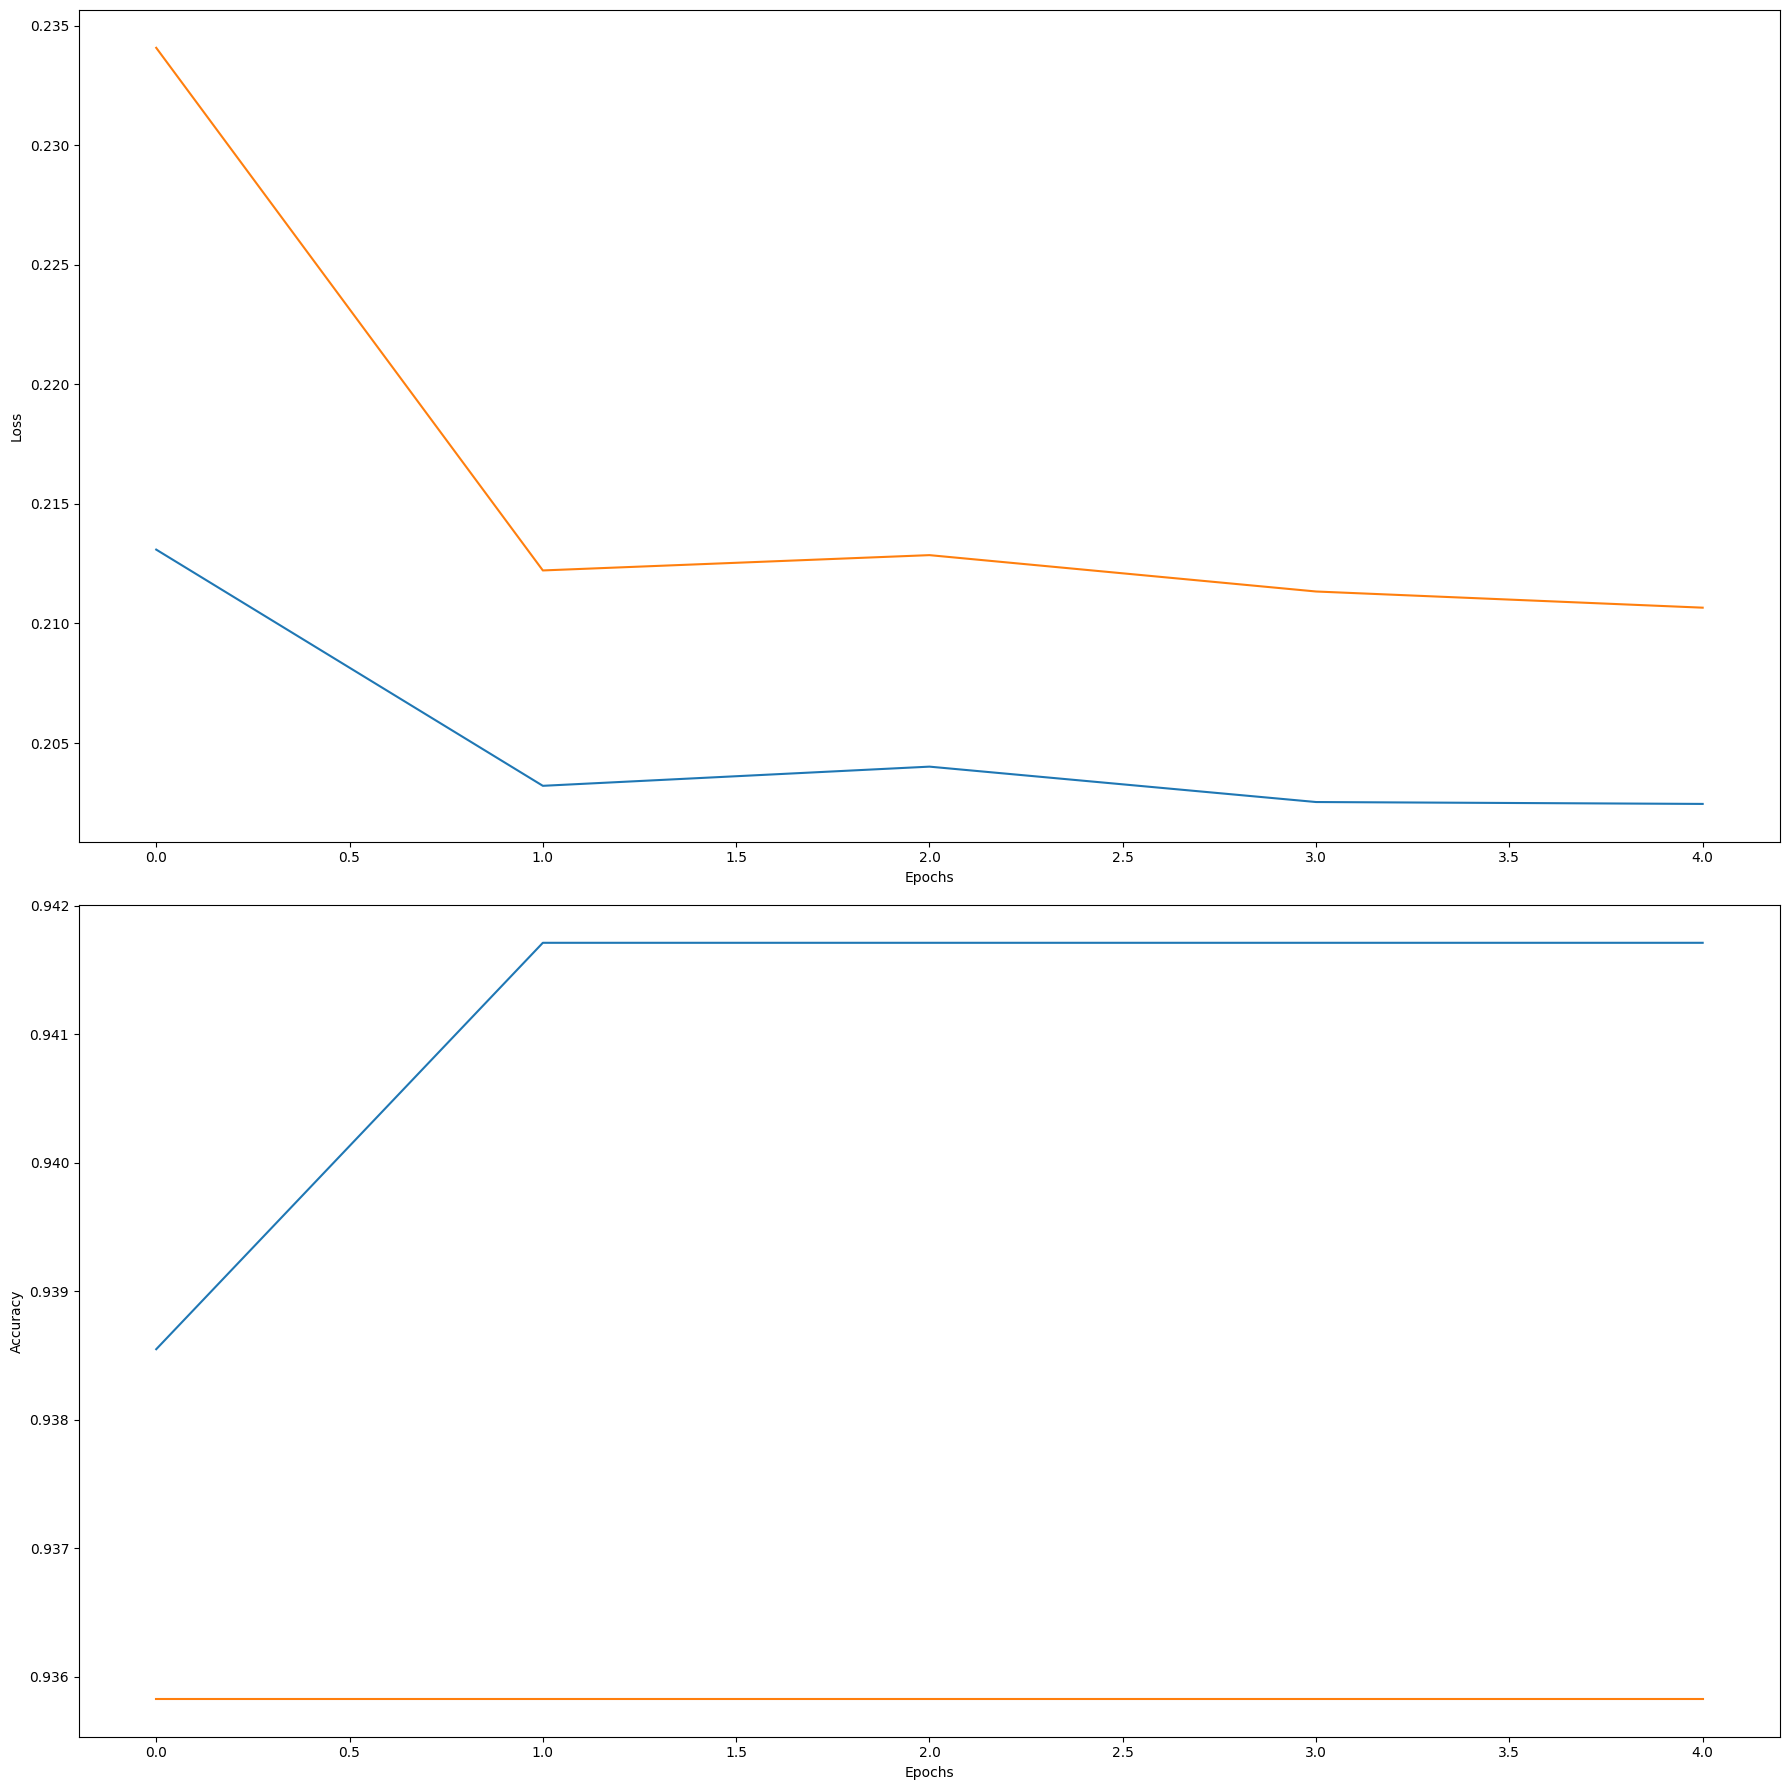

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(18, 18))

ax[0].plot(history['loss'], label='train_loss')
ax[0].plot(history['val_loss'], label='val_loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')


ax[1].plot(history['accuracy'], label='accuracy')
ax[1].plot(history['val_accuracy'], label='val_accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

Word2Vec и GloVe не дали прироста при использовании линейных моделей, однако при обучении GRU/LSTM поверх эмбеддингов удалось улучшить качество (accuracy/F1 ≈ 0.94). Это подтверждает важность учёта последовательной структуры текста для эффективного использования эмбеддингов.

#### 4.4. BERT

In [31]:
clf = BertClassifierSimple(epochs=3, batch_size=16, max_length=128, lr=2e-5)
train_loader, val_loader = clf.dataloaders(X_train, y_train, X_val, y_val)
clf.fit(train_loader, val_loader)

Map:   0%|          | 0/22530 [00:00<?, ? examples/s]

Map:   0%|          | 0/7510 [00:00<?, ? examples/s]

1 / 3:   0%|          | 0/1409 [00:00<?, ?it/s]

2 / 3:   0%|          | 0/1409 [00:00<?, ?it/s]

3 / 3:   0%|          | 0/1409 [00:00<?, ?it/s]

In [32]:
y_true, y_pred = clf.predict_loader(val_loader)
print(classification_report(y_true, y_pred))

predict:   0%|          | 0/470 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



На следующем этапе была обучена трансформерная модель BERT, способная учитывать глубокий двусторонний контекст и сложные зависимости между токенами. Теоретически BERT является более мощной архитектурой по сравнению с рекуррентными сетями.

Однако по результатам оценки на тестовой выборке модель показала качество, сопоставимое с baseline и линейными моделями:

* accuracy ≈ 0.93

* F1 ≈ 0.93

* метрики precision / recall по классам совпадают с ранее полученными значениями

Таким образом, использование BERT в данной задаче не привело к улучшению качества по сравнению с GRU/LSTM, несмотря на более сложную архитектуру.